In [311]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Added for plotting functions
import concurrent.futures # Added for parallel data loading
import hashlib # Added for caching
import re # Added for regex operations in data loading
from pathlib import Path # Added for Path object usage
from tqdm.notebook import tqdm # Added for progress bar in data loading

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize

from google.colab import drive
drive.mount('/content/drive')

if torch.cuda.is_available():
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("☁ᐢ No GPU detected — training will be slower")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ GPU detected: NVIDIA A100-SXM4-40GB


In [312]:
class CFG:
    # Paths
    DATA_DIR = "/content/drive/MyDrive/RMGDataset"
    PD_SIM_DIR = "/content/drive/MyDrive/RMGDataset_PD_sim_new"
    PT_SIM_DIR = "/content/drive/MyDrive/RMGDataset_PT_sim_new"
    SAVE_DIR = "/content/drive/MyDrive/RMG_Project/checkpoints"

    # Training Hyperparameters
    BATCH_SIZE = 32
    EPOCHS = 30
    LR = 1e-3
    WEIGHT_DECAY = 1e-4
    SEED = 42
    NUM_WORKERS = 2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    FOCAL_GAMMA = 2.0

    # Model Architecture - Ultra-Lightweight Edge Configuration
    N_CHANNELS = 8
    N_POINTS = 300
    N_GESTURES = 11
    N_TREMORS = 3
    HIDDEN_DIMS = [64, 128, 256]
    KERNEL_SIZE = 7
    DROPOUT = 0.6

    # Augmentation Probabilities
    AUG_NOISE_PROB = 0.8
    AUG_SHIFT_PROB = 0.8
    AUG_SCALE_PROB = 0.8
    AUG_CUTOUT_PROB = 0.8

    # Other configurations
    S_PARAMS = ["S11", "S22", "S12", "S21"]
    CSV_SUFFIX = ".csv"
    EXPERIMENT_TAG = "multitask_cnn"

    # Participant -> Subject mapping
    SUBJECT_MAP = {
        **{f"P{i:02d}": "S1" for i in range(1,  7)},
        **{f"P{i:02d}": "S2" for i in range(7,  13)},
        **{f"P{i:02d}": "S3" for i in range(13, 19)},
    }

# Ensure SAVE_DIR exists and set seeds
os.makedirs(CFG.SAVE_DIR, exist_ok=True)
torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.SEED)

In [313]:
# ============================================================
# 2. DATA LOADING UTILITIES
# ============================================================

def load_sample(rep_info: dict):
    gesture_dir  = Path(rep_info['gesture_dir'])
    pid          = rep_info['pid']
    gesture      = rep_info['gesture']
    iteration_id = rep_info['iteration_id']
    channels     = []

    try:
        all_files = [f for f in os.listdir(gesture_dir) if f.endswith(CFG.CSV_SUFFIX)]
    except:
        return None, False

    actual_pid_prefix = pid
    if all_files:
        m = re.search(r'(P\d{2,3})', all_files[0])
        if m: actual_pid_prefix = m.group(1)

    for sparam in CFG.S_PARAMS:
        match = next((f for f in all_files if (
            actual_pid_prefix in f and gesture in f and
            sparam in f and f"iter{iteration_id}" in f)), None)
        if not match: return None, False
        try:
            df = pd.read_csv(gesture_dir / match, header=None,
                             skiprows=1, engine='c')   # ← 'c' engine is faster
            mag_vals   = df.iloc[:, 1].values.astype(np.float32)
            phase_vals = df.iloc[:, 2].values.astype(np.float32) if df.shape[1] >= 3 else np.zeros_like(mag_vals)
            if len(mag_vals) != CFG.N_POINTS:
                x_old = np.linspace(0, 1, len(mag_vals))
                x_new = np.linspace(0, 1, CFG.N_POINTS)
                mag_vals   = np.interp(x_new, x_old, mag_vals).astype(np.float32)
                phase_vals = np.interp(x_new, x_old, phase_vals).astype(np.float32)
            channels.extend([mag_vals, phase_vals])
        except:
            return None, False
    return np.stack(channels, axis=0), True

def _build_dataframe_from_root(data_dir: str, tremor_label: int):
    rows, all_repetition_paths, gesture_set = [], [], set()
    for root, _, files in os.walk(data_dir):
        if not any(f.endswith(CFG.CSV_SUFFIX) for f in files): continue
        root_path = Path(root)
        pid = next((f"P{int(m.group(1)):02d}"
                    for part in root_path.parts
                    for m in [re.search(r'P(\d+)', part)] if m), None)
        if not pid: continue
        gesture      = root_path.name
        unique_iters = {int(m.group(1)) for f in files
                        if 'S11' in f
                        for m in [re.search(r'_iter(\d+)', f)] if m}
        for it_id in unique_iters:
            gesture_set.add(gesture)
            all_repetition_paths.append({
                'gesture_dir': root, 'gesture': gesture,
                'pid': pid, 'iteration_id': it_id
            })

    rows = []
    # Use ThreadPoolExecutor for parallel file reading (I/O bound)
    with concurrent.futures.ThreadPoolExecutor(max_workers=CFG.NUM_WORKERS) as executor:
        results = list(tqdm(executor.map(load_sample, all_repetition_paths),
                            total=len(all_repetition_paths),
                            desc=f"Loading {Path(data_dir).name}", leave=False))

    for i, (signal, ok) in enumerate(results):
        if ok:
            rep_info = all_repetition_paths[i]
            rows.append({
                'signal':  signal,
                'gesture': rep_info['gesture'],
                'tremor':  tremor_label,
                'pid':     rep_info['pid'],
                'subject': CFG.SUBJECT_MAP.get(rep_info['pid'], 'unknown'),
            })
    return pd.DataFrame(rows), gesture_set

def _cache_path(data_dir: str) -> str:
    """Unique cache filename based on the directory path, stored in Drive."""
    tag = hashlib.md5(data_dir.encode()).hexdigest()[:8]
    name = Path(data_dir).name
    return f"{CFG.SAVE_DIR}/{name}_{tag}.npz"

def _save_cache(df: pd.DataFrame, gesture_set: set, cache_file: str):
    signals  = np.stack(df['signal'].values)
    gestures = np.array(df['gesture'].values)
    tremors  = df['tremor'].values.astype(np.int32)
    pids     = np.array(df['pid'].values)
    subjects = np.array(df['subject'].values)
    gesture_list = np.array(sorted(gesture_set))
    np.savez_compressed(cache_file,
        signals=signals, gestures=gestures,
        tremors=tremors, pids=pids,
        subjects=subjects, gesture_list=gesture_list)
    print(f"  ‹ Cache saved → {cache_file}")

def _load_cache(cache_file: str, tremor_label: int):
    data = np.load(cache_file, allow_pickle=True)
    df = pd.DataFrame({
        'signal':  list(data['signals']),
        'gesture': data['gestures'],
        'tremor':  tremor_label,
        'pid':     data['pids'],
        'subject': data['subjects'],
    })
    gesture_set = set(data['gesture_list'].tolist())
    print(f"  ☑ Loaded from cache: {len(df)} samples")
    return df, gesture_set

def build_combined_dataframe(h_dir, pd_dir, pt_dir, use_cache=True):
    dfs, gsets = [], []
    for data_dir, tremor_label in [(h_dir, 0), (pd_dir, 1), (pt_dir, 2)]:
        cache_file = _cache_path(data_dir)
        if use_cache and os.path.exists(cache_file):
            df, gset = _load_cache(cache_file, tremor_label)
        else:
            df, gset = _build_dataframe_from_root(data_dir, tremor_label)
            if use_cache and len(df) > 0: _save_cache(df, gset, cache_file)
        dfs.append(df)
        gsets.append(gset)

    combined_df  = pd.concat(dfs, ignore_index=True)
    all_gestures = sorted(set().union(*gsets))
    label_map    = {g: i for i, g in enumerate(all_gestures)}
    combined_df['label'] = combined_df['gesture'].map(label_map)
    print(f"\n☑ Dataset: {len(combined_df)} samples ({len(dfs[0])} Healthy + {len(dfs[1])} PD + {len(dfs[2])} PT)")
    return combined_df, all_gestures, label_map

In [314]:
class ResBlock1D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 7, dropout: float = 0.2, stride: int = 1):
        super().__init__()
        pad = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=pad, bias=False),
            nn.BatchNorm1d(out_channels), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, padding=pad, bias=False),
            nn.BatchNorm1d(out_channels))

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels))

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Conv1d(out_channels, out_channels // 4, 1),
            nn.ReLU(), nn.Conv1d(out_channels // 4, out_channels, 1), nn.Sigmoid())
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.block(x)
        out = out * self.se(out)
        return self.relu(out + residual)

def build_model(num_classes: int):
    # Dynamically instantiate the advanced dual-stream multi-task model
    model = SParamMultiTaskModel(num_g=num_classes, num_t=CFG.N_TREMORS, hidden_dims=CFG.HIDDEN_DIMS)
    return model.to(CFG.DEVICE)

In [315]:
def load_backbone_weights(model, ckpt_path):
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"  [WARN] Checkpoint not found at {ckpt_path}. Training from scratch.")
        return model

    print(f"  [INFO] Loading backbone weights from: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=CFG.DEVICE)
    state_dict = checkpoint.get('model_state', checkpoint) # Handle different save formats

    # Filter out head weights (gesture_head, tremor_head) to only load the backbone (stem, stages)
    backbone_dict = {k: v for k, v in state_dict.items() if 'head' not in k}

    model_dict = model.state_dict()
    model_dict.update(backbone_dict)
    model.load_state_dict(model_dict)

    print(f"  [SUCCESS] Backbone weights loaded (excluding task heads).")
    return model

In [316]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss)
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

@torch.no_grad()
def validate(model, loader, criterion_gesture, criterion_tremor, log_task_weights, gesture_names=None):
    model.eval()
    total_loss, all_g_preds, all_g_labels, all_t_preds, all_t_probs, all_t_labels = 0, [], [], [], [], []

    for signals, g_labels, t_labels in loader:
        signals, g_labels, t_labels = signals.to(CFG.DEVICE), g_labels.to(CFG.DEVICE), t_labels.to(CFG.DEVICE).long()
        g_logits, t_logits = model(signals)

        loss_g = criterion_gesture(g_logits, g_labels)
        loss_t = criterion_tremor(t_logits, t_labels)
        loss = (loss_g * torch.exp(-log_task_weights[0]) + log_task_weights[0] +
                loss_t * torch.exp(-log_task_weights[1]) + log_task_weights[1])

        total_loss += loss.item() * signals.size(0)

        all_g_preds.extend(g_logits.argmax(1).cpu().numpy())
        all_g_labels.extend(g_labels.cpu().numpy())
        all_t_preds.extend(t_logits.argmax(1).cpu().numpy())
        all_t_probs.extend(t_logits.softmax(dim=1).cpu().numpy())
        all_t_labels.extend(t_labels.cpu().numpy())

    n = len(all_g_labels)
    # Using label_binarize from sklearn.preprocessing
    from sklearn.preprocessing import label_binarize
    t_auc = roc_auc_score(label_binarize(all_t_labels, classes=[0,1,2]), np.array(all_t_probs), multi_class='ovr', average='macro')
    return (total_loss / n, accuracy_score(all_g_labels, all_g_preds),
            f1_score(all_g_labels, all_g_preds, average="macro", zero_division=0),
            accuracy_score(all_t_labels, all_t_preds), t_auc,
            all_g_preds, all_g_labels, all_t_preds, all_t_labels, all_t_probs)

In [317]:
class SqueezeExcitation1D(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        bottleneck_ch = max(1, channels // reduction)
        self.fc = nn.Sequential(
            nn.Linear(channels, bottleneck_ch, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck_ch, channels, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b, c, _ = x.size()
        y = x.mean(dim=2)
        y = self.fc(y).view(b, c, 1)
        return x * y

class SEResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.InstanceNorm1d(out_ch, affine=True)
        self.dropout = nn.Dropout(p=dropout)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.InstanceNorm1d(out_ch, affine=True)
        self.se = SqueezeExcitation1D(out_ch)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.InstanceNorm1d(out_ch, affine=True))

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out = self.se(out) + self.shortcut(x)
        return F.relu(out)

class SParamMultiTaskModel(nn.Module):
    def __init__(self, num_g, num_t, hidden_dims=[64, 128, 256]):
        super().__init__()

        # --- GESTURE STEMS (Processes Absolute Envelopes) ---
        self.mag_stem_g = nn.Sequential(
            nn.Conv1d(4, hidden_dims[0]//2, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(hidden_dims[0]//2), nn.ReLU())
        self.phase_stem_g = nn.Sequential(
            nn.Conv1d(4, hidden_dims[0]//2, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm1d(hidden_dims[0]//2), nn.ReLU())
        self.gesture_stages = nn.Sequential(
            ResBlock1D(hidden_dims[0], hidden_dims[0], kernel_size=7, dropout=CFG.DROPOUT * 0.5),
            ResBlock1D(hidden_dims[0], hidden_dims[1], kernel_size=7, dropout=CFG.DROPOUT * 0.5, stride=2),
            ResBlock1D(hidden_dims[1], hidden_dims[2], kernel_size=7, dropout=CFG.DROPOUT * 0.5, stride=2))

        # --- RESTRUCTURED TREMOR BRANCH: Dual CNN + Spectral Fusion ---
        self.mag_stem_t = nn.Sequential(
            nn.Conv1d(4, hidden_dims[0]//2, 7, stride=2, padding=3, bias=False),
            nn.InstanceNorm1d(hidden_dims[0]//2, affine=True), nn.ReLU())
        self.phase_stem_t = nn.Sequential(
            nn.Conv1d(4, hidden_dims[0]//2, 7, stride=2, padding=3, bias=False),
            nn.InstanceNorm1d(hidden_dims[0]//2, affine=True), nn.ReLU())

        self.tremor_stages = nn.Sequential(
            SEResBlock(hidden_dims[0], hidden_dims[0], stride=1, dropout=CFG.DROPOUT),
            nn.Conv1d(hidden_dims[0], hidden_dims[1], kernel_size=3, stride=2, padding=2, dilation=2, bias=False),
            nn.InstanceNorm1d(hidden_dims[1], affine=True), nn.ReLU(),
            nn.Conv1d(hidden_dims[1], hidden_dims[2], kernel_size=3, stride=2, padding=4, dilation=4, bias=False),
            nn.InstanceNorm1d(hidden_dims[2], affine=True), nn.ReLU())

        # Spectral projection layer: processes the 151-bin RFFT of the 4 phase channels
        # (300 points real FFT yields 151 unique frequency bins)
        self.spectral_projection = nn.Sequential(
            nn.Linear(4 * 151, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3)
        )

        # Output Heads
        self.head_g = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(hidden_dims[2], 128), nn.ReLU(), nn.Dropout(p=0.4),
            nn.Linear(128, num_g))

        # Combined classifier head receives both the pooled spatial features AND explicit spectral peaks
        self.head_t = nn.Sequential(
            nn.Linear(hidden_dims[2] + 128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(64, num_t))

    def forward(self, x):
        # === STREAM 1: Gesture Stream ===
        mag_raw = x[:, [0, 2, 4, 6], :]
        phase_raw = x[:, [1, 3, 5, 7], :]
        g_feat = self.gesture_stages(torch.cat([self.mag_stem_g(mag_raw), self.phase_stem_g(phase_raw)], dim=1))

        # === STREAM 2: Tremor Stream ===
        x_diff = torch.diff(x, dim=2)
        x_diff = F.pad(x_diff, (0, 1), "constant", 0)

        mag_diff = x_diff[:, [0, 2, 4, 6], :]
        phase_diff = x_diff[:, [1, 3, 5, 7], :]

        # 2a. Standard Spatial CNN Features
        spatial_t = self.tremor_stages(torch.cat([self.mag_stem_t(mag_diff), self.phase_stem_t(phase_diff)], dim=1))
        spatial_pooled = F.adaptive_avg_pool1d(spatial_t, 1).flatten(1) # Shape: (B, hidden_dims[2])

        # 2b. Explicit Physics-Informed RFFT Features
        # Compute the real FFT across the phase channels to isolate spatial periods cleanly
        fft_features = torch.fft.rfft(phase_diff, dim=-1)
        fft_mag = torch.abs(fft_features).flatten(1) # Shape: (B, 4 * 151)
        spectral_pooled = self.spectral_projection(fft_mag) # Shape: (B, 128)

        # 2c. Concatenate high-level visual features with exact physical spectrum peaks
        t_feat = torch.cat([spatial_pooled, spectral_pooled], dim=1)

        return self.head_g(g_feat), self.head_t(t_feat)

class SParamDatasetIntegrated(Dataset):
    def __init__(self, df, session_stats, is_train=False):
        self.df = df.reset_index(drop=True)
        self.session_stats = session_stats
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        session_key = str(row['pid']) + "_" + str(row.get('arm', 'Default'))
        signal = torch.tensor(row["signal"], dtype=torch.float32)

        if self.session_stats and session_key in self.session_stats:
            stats = self.session_stats[session_key]
            signal = (signal - stats['mean']) / (stats['std'] + 1e-6)

        if self.is_train:
            signal = self._augment(signal)

        return signal, int(row["label"]), int(row["tremor"])

    def _augment(self, signal: torch.Tensor) -> torch.Tensor:
        # Separate indices
        mag_idx = [0, 2, 4, 6]
        phase_idx = [1, 3, 5, 7]

        # 1. Additive noise
        if torch.rand(1) < CFG.AUG_NOISE_PROB:
            signal[mag_idx, :] += torch.randn((4, signal.shape[1])) * 0.01
            signal[phase_idx, :] += torch.randn((4, signal.shape[1])) * 0.005

        # 2. Shift (Spatial/Frequency point translation)
        if torch.rand(1) < CFG.AUG_SHIFT_PROB:
            shift = torch.randint(-15, 15, (1,)).item()
            signal = torch.roll(signal, shift, dims=1)

        # 3. Physically accurate scaling
        if torch.rand(1) < CFG.AUG_SCALE_PROB:
            scale = torch.empty(1).uniform_(0.9, 1.1).item()
            signal[mag_idx, :] *= scale  # Multiplicative for reflection/transmission coefficients

        # 4. Spectral Masking (new addition)
        if torch.rand(1) < 0.5: # 50% chance to mask a small chunk of the spectrum
            mask_width = torch.randint(10, 40, (1,)).item()
            start_point = torch.randint(0, signal.shape[1] - mask_width, (1,)).item()
            # Zero out a random band of frequency points across all channels
            signal[:, start_point : start_point + mask_width] = 0.0

        return signal

In [318]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def create_dataloaders(train_df, test_df, train_session_stats, test_session_stats):
    # Pass train stats to train dataset, test stats to validation dataset
    train_ds = SParamDatasetIntegrated(train_df, train_session_stats, is_train=True)
    val_ds   = SParamDatasetIntegrated(test_df, test_session_stats, is_train=False)

    train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                              num_workers=CFG.NUM_WORKERS, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,
                            num_workers=CFG.NUM_WORKERS)
    return train_loader, val_loader

def train_one_epoch(model, train_loader, optimizer, criterion_gesture, criterion_tremor, log_task_weights):
    model.train()
    running_loss, correct_g, total_samples = 0.0, 0, 0

    for signals, g_labels, t_labels in train_loader:
        signals = signals.to(CFG.DEVICE)
        g_labels = g_labels.to(CFG.DEVICE)
        t_labels = t_labels.to(CFG.DEVICE).long()

        optimizer.zero_grad()
        g_logits, t_logits = model(signals)

        loss_g = criterion_gesture(g_logits, g_labels)
        loss_t = criterion_tremor(t_logits, t_labels)

        # We give gesture loss a solid baseline and scale tremor loss to match magnitudes
        loss = loss_g + 2.0 * loss_t

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * signals.size(0)
        correct_g += (g_logits.argmax(1) == g_labels).sum().item()
        total_samples += signals.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_g / total_samples
    return epoch_loss, epoch_acc

def save_checkpoint(model, log_task_weights, epoch, fold_idx, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    torch.save(
        {
            'model_state': model.state_dict(),
            'log_task_weights': log_task_weights.detach().cpu().numpy(),
            'epoch': epoch
        }, Path(save_dir) / f"best_multitask_model_fold{fold_idx}.pth")

# FIX: Added train_session_stats and test_session_stats as parameters
def train_fold(fold_idx, train_df, test_df, gesture_names, train_session_stats, test_session_stats, pretrained_ckpt=None):
    print(f"\n🚀 Initializing Training Pipeline for Fold {fold_idx + 1}...")

    # 2. Instantiate custom datasets & loaders with independent normalization matrices
    train_loader, val_loader = create_dataloaders(train_df, test_df, train_session_stats, test_session_stats)

    # 3. Model construction with dual-stem backbone
    model = build_model(num_classes=len(gesture_names))
    if pretrained_ckpt:
        model = load_backbone_weights(model, pretrained_ckpt)

    # 4. Initialize trainable multi-task homoscedastic uncertainty log weights
    log_task_weights = nn.Parameter(torch.zeros(2, device=CFG.DEVICE))

    # 5. Criterions and Optimization Matrix
    criterion_gesture = nn.CrossEntropyLoss(label_smoothing=0.15).to(CFG.DEVICE)
    # Order of classes in dataset: [Healthy, PD-sim, PT-sim]
    # Increase the loss penalty specifically for the under-performing PT class
    tremor_weights = torch.tensor([1.0, 1.0, 1.6], device=CFG.DEVICE)
    criterion_tremor  = nn.CrossEntropyLoss(weight=tremor_weights, label_smoothing=0.1).to(CFG.DEVICE)

    optimizer = optim.AdamW(
        list(model.parameters()) + [log_task_weights],
        lr=1e-4,
        weight_decay=1e-4
    )
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [], "train_gest_acc": [],
        "val_gest_acc": [], "val_gest_f1": [], "val_trem_acc": [], "val_trem_auc": []
    }
    best_f1 = 0.0
    best_results = {}

    # 6. Training Execution Loop
    for epoch in range(1, CFG.EPOCHS + 1):
        epoch_loss, epoch_acc = train_one_epoch(model, train_loader, optimizer, criterion_gesture, criterion_tremor, log_task_weights)

        # 7. Comprehensive Evaluation Pass
        val_metrics = validate(
            model, val_loader, criterion_gesture, criterion_tremor, log_task_weights, gesture_names
        )
        val_loss, val_acc, val_f1, val_t_acc, val_t_auc = val_metrics[0:5]
        g_preds, g_labels, t_preds, t_labels, t_probs = val_metrics[5:10]

        # Log performance histories
        history["train_loss"].append(epoch_loss)
        history["val_loss"].append(val_loss)
        history["train_gest_acc"].append(epoch_acc)
        history["val_gest_acc"].append(val_acc)
        history["val_gest_f1"].append(val_f1)
        history["val_trem_acc"].append(val_t_acc)
        history["val_trem_auc"].append(val_t_auc)

        print(f"Epoch {epoch:02d}/{CFG.EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.3f} | "
              f"Val Loss: {val_loss:.4f} Gest F1: {val_f1:.3f} Trem AUC: {val_t_auc:.3f}")

        # Save checkpoints when macro F1 clears previous thresholds
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_results = {
                "history": history, "g_preds": g_preds, "g_labels": g_labels,
                "t_labels": t_labels, "t_probs": t_probs
            }
            save_checkpoint(model, log_task_weights, epoch, fold_idx, CFG.SAVE_DIR)

        scheduler.step()

    return best_results

In [319]:
def compute_session_stats(df):
    stats = {}
    df = df.copy()

    # Vectorized fallback: safely handle whether the 'arm' column exists or not
    if 'arm' in df.columns:
        df['session_id'] = df['pid'].astype(str) + "_" + df['arm'].astype(str)
    else:
        df['session_id'] = df['pid'].astype(str) + "_Default"

    # Isolate healthy rows internally to establish the clean biological baseline
    healthy_df = df[df['tremor'] == 0]

    for session in df['session_id'].unique():
        session_healthy = healthy_df[healthy_df['session_id'] == session]

        # Fallback security check in case a split lacks healthy rows for a session
        if len(session_healthy) == 0:
            s_signals = np.stack(df[df['session_id'] == session]['signal'].values)
        else:
            s_signals = np.stack(session_healthy['signal'].values)  # (N, 8, 300)

        # Compute frequency-bin-wise parameters (axis=0 keeps the 300 bins independent)
        mean = s_signals.mean(axis=0, keepdims=True)  # Shape: (1, 8, 300)
        std  = s_signals.std(axis=0,  keepdims=True)   # Shape: (1, 8, 300)

        # Safe noise floor capping to prevent division-by-zero or gradient explosion
        std  = np.where(std < 1e-4, 1.0, std)

        stats[session] = {
            'mean': torch.tensor(mean.squeeze(0), dtype=torch.float32),
            'std':  torch.tensor(std.squeeze(0),  dtype=torch.float32)
        }

    print(f"✅ Successfully computed frequency-bin baselines for {len(stats)} sessions.")
    return stats

In [320]:

# ============================================================
#  CELL 7: PLOTTING  & VISUALIZATION
# ============================================================
def plot_history(history, fold_idx):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(f"Fold {fold_idx+1} — Training History", fontsize=13)
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label="Train", linewidth=2)
    axes[0].plot(epochs, history["val_loss"],   label="Val",   linewidth=2)
    axes[0].set_title("Total Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, history["train_gest_acc"], label="Train", linewidth=2)
    axes[1].plot(epochs, history["val_gest_acc"],   label="Val",   linewidth=2)
    axes[1].set_title("Gesture Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[2].plot(epochs, history["val_gest_f1"], color="green", linewidth=2)
    axes[2].set_title("Gesture Macro F1"); axes[2].grid(alpha=0.3)
    axes[3].plot(epochs, history["val_trem_auc"], color="crimson", linewidth=2, label="Tremor AUC")
    axes[3].plot(epochs, history["val_trem_acc"], color="orange", linewidth=2, linestyle="--", label="Tremor Acc")
    axes[3].set_title("Tremor Detection"); axes[3].legend(); axes[3].grid(alpha=0.3)
    for ax in axes: ax.set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig(f"/content/{CFG.EXPERIMENT_TAG}_fold{fold_idx+1}_history.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def plot_confusion(labels, preds, gesture_names, tag=""):
    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=gesture_names, yticklabels=gesture_names,
                ax=ax, cbar_kws={'label': 'Proportion'})
    ax.set_xlabel("Predicted", fontsize=11); ax.set_ylabel("True", fontsize=11)
    ax.set_title(f"Gesture Confusion Matrix {tag}", fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"/content/{CFG.EXPERIMENT_TAG}_gesture_confusion{tag}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig

def plot_tremor_confusion(t_labels, t_probs, tag=""):
    from sklearn.metrics import roc_curve
    # FIXED: `label_binarize` is now in sklearn.preprocessing
    from sklearn.preprocessing import label_binarize
    t_labels = np.array(t_labels)
    t_probs = np.array(t_probs)
    t_preds = t_probs.argmax(axis=1)
    classes = ["Healthy", "PD-sim", "PT-sim"]

    cm = confusion_matrix(t_labels, t_preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Tremor Detection (3-Class) {tag}", fontsize=13)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
                xticklabels=classes, yticklabels=classes, ax=axes[0])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True"); axes[0].set_title("Confusion Matrix")

    # Multi-class ROC curve (One-vs-Rest)
    y_bin = label_binarize(t_labels, classes=[0, 1, 2])
    for i in range(3):
        fpr, tpr, _ = roc_curve(y_bin[:, i], t_probs[:, i])
        axes[1].plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc_score(y_bin[:, i], t_probs[:, i]):.3f})")

    axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
    axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title("ROC Curve (OvR)"); axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"/content/{CFG.EXPERIMENT_TAG}_tremor{tag}.png", dpi=150, bbox_inches='tight')
    plt.show()
    return fig

  ☑ Loaded from cache: 2376 samples
  ☑ Loaded from cache: 2376 samples
  ☑ Loaded from cache: 2376 samples

☑ Dataset: 7128 samples (2376 Healthy + 2376 PD + 2376 PT)
  ᔅ Train subjects: ['S3' 'S2'] | Test subjects: ['S1']
  Train samples: 4752 | Test samples: 2376
  Tremor distribution (Test): {0: 792, 1: 792, 2: 792}

— Checking for participant ID overlap between train and test sets:
  ✅ No overlapping participant IDs found. All 18 participant IDs are unique across splits.

[INFO] Computing biological baseline profiles independently for splits...
✅ Successfully computed frequency-bin baselines for 12 sessions.
✅ Successfully computed frequency-bin baselines for 6 sessions.

🚀 Initializing Training Pipeline for Fold 1...
Epoch 01/30 | Train Loss: 19.8373 Acc: 0.139 | Val Loss: 4.9905 Gest F1: 0.144 Trem AUC: 0.750
Epoch 02/30 | Train Loss: 6.2759 Acc: 0.218 | Val Loss: 3.7469 Gest F1: 0.163 Trem AUC: 0.830
Epoch 03/30 | Train Loss: 4.1595 Acc: 0.278 | Val Loss: 3.4571 Gest F1: 0.195 

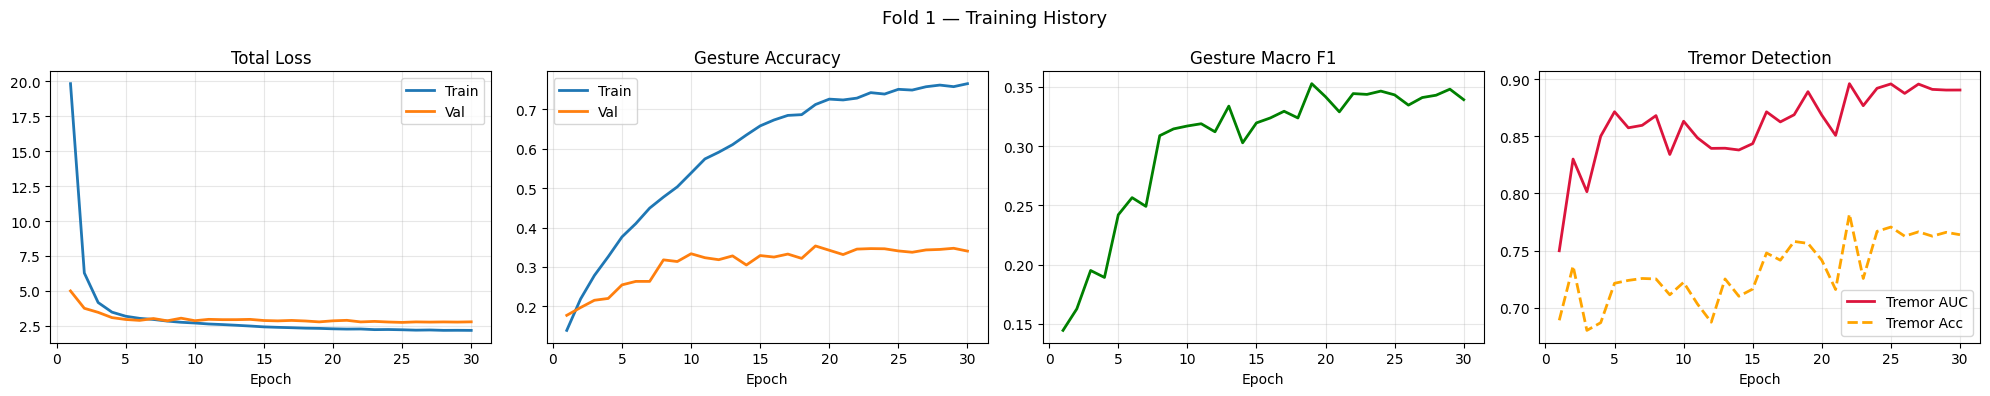

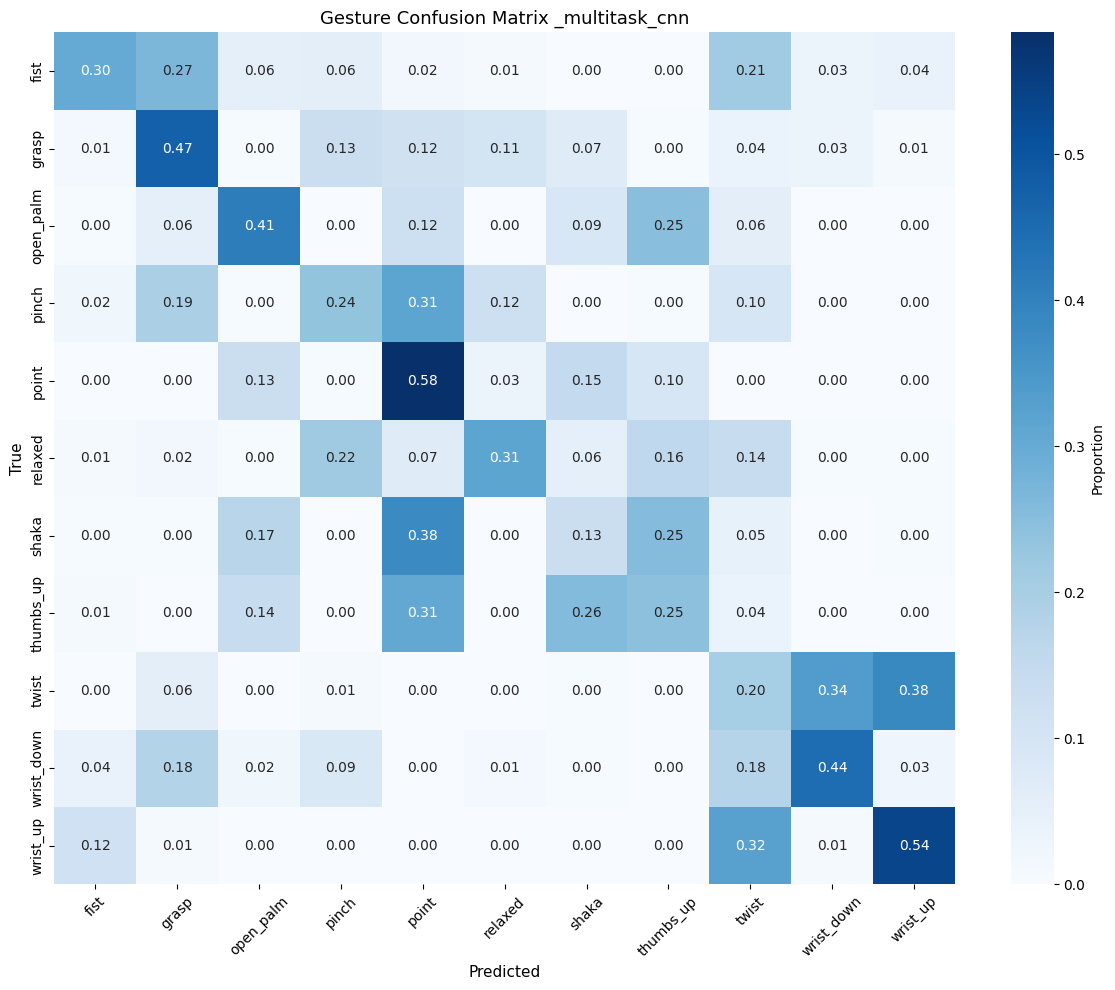

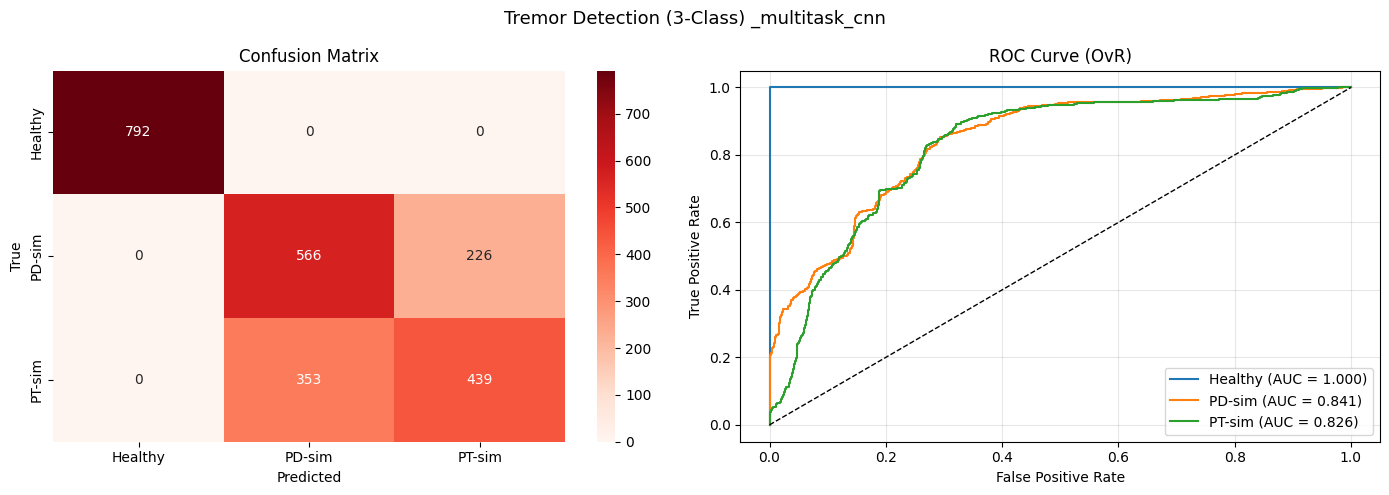


═ Gesture classification report:
              precision    recall  f1-score   support

        fist       0.57      0.30      0.39       216
       grasp       0.37      0.47      0.42       216
   open_palm       0.43      0.41      0.42       216
       pinch       0.31      0.24      0.27       216
       point       0.31      0.58      0.40       216
     relaxed       0.52      0.31      0.39       216
       shaka       0.17      0.13      0.15       216
   thumbs_up       0.24      0.25      0.24       216
       twist       0.15      0.20      0.17       216
  wrist_down       0.52      0.44      0.48       216
    wrist_up       0.53      0.54      0.53       216

    accuracy                           0.35      2376
   macro avg       0.38      0.35      0.35      2376
weighted avg       0.38      0.35      0.35      2376


✂️ Tremor detection report (3-class):
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       792
     

In [321]:
def main():
    # ── Load combined dataset with caching ───────
    df, gesture_names, _ = build_combined_dataframe(
        CFG.DATA_DIR, CFG.PD_SIM_DIR, CFG.PT_SIM_DIR, use_cache=True
    )

    if len(df) == 0:
        print("X No data loaded. Check data directory paths.")
        return df, []

    # ── Custom train/test split to avoid Subject overlap ──
    # Group your dataframe by the underlying real subject
    df['subject'] = df['pid'].map(CFG.SUBJECT_MAP)

    # Example for Fold 1: Train on S2 and S3, Test completely on S1
    train_df = df[df['subject'].isin(['S2', 'S3'])].copy()
    test_df  = df[df['subject'] == 'S1'].copy()

    print(f"  ᔅ Train subjects: {train_df['subject'].unique()} | Test subjects: {test_df['subject'].unique()}")
    print(f"  Train samples: {len(train_df)} | Test samples: {len(test_df)}")
    print(f"  Tremor distribution (Test): {test_df['tremor'].value_counts().to_dict()}")

    # — Checking for participant ID overlap between train and test sets:
    print('\n— Checking for participant ID overlap between train and test sets:')
    train_pids = set(train_df['pid'].unique())
    test_pids = set(test_df['pid'].unique())
    overlap_pids = train_pids.intersection(test_pids)

    if len(overlap_pids) == 0:
        print(f'  ✅ No overlapping participant IDs found. All {len(train_pids) + len(test_pids)} participant IDs are unique across splits.')
    else:
        print(f'  ☢️ WARNING: {len(overlap_pids)} overlapping participant IDs found: {overlap_pids}')

    # ── Compute session statistics strictly after splitting to prevent leakage ──
    print("\n[INFO] Computing biological baseline profiles independently for splits...")
    train_healthy = train_df[train_df['tremor'] == 0]
    train_session_stats = compute_session_stats(train_healthy)

    test_healthy = test_df[test_df['tremor'] == 0]
    test_session_stats = compute_session_stats(test_healthy)

    # ── Train configuration ───────
    PRETRAINED_CKPT = None

    # Pass split-isolated session statistics dictionaries into train_fold
    result = train_fold(
        fold_idx=0, train_df=train_df, test_df=test_df,
        gesture_names=gesture_names,
        train_session_stats=train_session_stats,
        test_session_stats=test_session_stats,
        pretrained_ckpt=PRETRAINED_CKPT
)

    # ── Metrics & Visualization ───────
    experiment_tag = getattr(CFG, 'EXPERIMENT_TAG', 'default')
    plot_history(result["history"], fold_idx=0)
    plot_confusion(result["g_labels"], result["g_preds"], gesture_names, tag=f"_{experiment_tag}")
    plot_tremor_confusion(result["t_labels"], result["t_probs"], tag=f"_{experiment_tag}")

    print("\n═ Gesture classification report:")
    print(classification_report(result["g_labels"], result["g_preds"], target_names=gesture_names, zero_division=0))

    print("\n✂️ Tremor detection report (3-class):")
    t_preds = np.array(result["t_probs"]).argmax(axis=1)
    print(classification_report(result["t_labels"], t_preds, target_names=["Healthy", "PD-sim", "PT-sim"], zero_division=0))

    return df, result, train_session_stats, test_session_stats

# Execute
df_global, result_global, train_stats_global, test_stats_global = main()